## 1. Environment Setup

In [1]:
# Kaggle environment — lists all input files available for this competition


# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/comment-category-prediction-challenge/Sample.csv
/kaggle/input/competitions/comment-category-prediction-challenge/train.csv
/kaggle/input/competitions/comment-category-prediction-challenge/test.csv


## 2. Imports

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

# Scikit-learn: model selection, preprocessing, metrics
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score
)
from sklearn.utils.class_weight import compute_sample_weight
from scipy.sparse import hstack, csr_matrix

# Gradient boosting frameworks
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


## 3. Load Data

In [3]:
# Loading the training data, test data, and sample submission file

train_data = pd.read_csv('/kaggle/input/competitions/comment-category-prediction-challenge/train.csv')
test_data  = pd.read_csv('/kaggle/input/competitions/comment-category-prediction-challenge/test.csv')
sample_submission = pd.read_csv('/kaggle/input/competitions/comment-category-prediction-challenge/Sample.csv')

print("Training data shape :", train_data.shape)
print("Test data shape     :", test_data.shape)
print("Sample submission   :", sample_submission.shape)

print("\nTraining Data (first 5 rows)")
print(train_data.head())

print("\nTest Data (first 5 rows)")
print(test_data.head())

Training data shape : (198000, 15)
Test data shape     : (102000, 14)
Sample submission   : (102000, 2)

Training Data (first 5 rows)
                       created_date  post_id  emoticon_1  emoticon_2  \
0  2024-01-18 08:43:57.397508+00:00       73           0           0   
1  2024-03-24 21:43:11.490017+00:00       39           0           0   
2  2024-04-24 20:32:17.014931+00:00       31           0           1   
3  2023-05-28 22:00:14.214527+00:00       39           0           0   
4  2023-09-09 23:12:05.689498+00:00       39           0           0   

   emoticon_3  upvote  downvote  if_1  if_2 race religion gender  disability  \
0           0       0         1     0    10  NaN      NaN    NaN       False   
1           0       6         0     0     4  NaN      NaN    NaN       False   
2           1       0         0     0    10  NaN      NaN    NaN       False   
3           0       5         0     0    10  NaN      NaN    NaN       False   
4           0       0         0  

## 4. Exploratory Data Analysis (EDA)

I explore the dataset to understand its structure, identify feature types, check for missing values, and analyze the target distribution.

### 4.1 Data Overview

In [4]:
# Structure and summary statistics of the training data

print("Training Data Info:")
print(train_data.info())

print("\nTraining Data Statistics:")
print(train_data.describe())

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB
None

Training Data Statistics:
             post_id     emoticon_1     emotic

### 4.2 Feature Type Identification

In [5]:
# Separating columns by type — this guides our preprocessing strategy
# - Text features need vectorization (TF-IDF)
# - Numeric features need scaling (StandardScaler)
# - Categorical features need encoding (LabelEncoder)

text_columns     = ['comment']
date_columns     = ['created_date']
id_columns       = ['post_id']
numeric_columns  = ['emoticon_1', 'emoticon_2', 'emoticon_3',
                     'upvote', 'downvote', 'if_1', 'if_2']
categorical_columns = ['race', 'religion', 'gender', 'disability']
target_column    = 'label'

print("Feature Types:")
print("Text features       :", text_columns)
print("Date features       :", date_columns)
print("ID features         :", id_columns)
print("Numeric features    :", numeric_columns)
print("Categorical features:", categorical_columns)
print("Target              :", target_column)

Feature Types:
Text features       : ['comment']
Date features       : ['created_date']
ID features         : ['post_id']
Numeric features    : ['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2']
Categorical features: ['race', 'religion', 'gender', 'disability']
Target              : label


### 4.3 Missing Value Analysis

In [6]:
# Checking for missing values — important to handle before modeling

print("Missing Values in Training Data:")
missing_in_train = train_data.isnull().sum()
print(missing_in_train[missing_in_train > 0] if missing_in_train.sum() > 0
      else "No missing values in training data!")

print("\nMissing Values in Test Data:")
missing_in_test = test_data.isnull().sum()
print(missing_in_test[missing_in_test > 0] if missing_in_test.sum() > 0
      else "No missing values in test data!")

Missing Values in Training Data:
race        145423
religion    145423
gender      145423
comment          1
dtype: int64

Missing Values in Test Data:
race        75269
religion    75269
gender      75269
dtype: int64


### 4.4 Target Label Distribution

In [7]:
# Understanding class balance — imbalanced classes will need special handling
# (e.g., class_weight='balanced', sample weights)

print("Target Label Distribution:")
label_counts = train_data['label'].value_counts().sort_index()
print(label_counts)
print("\nClass proportions:")
print(round(label_counts / len(train_data) * 100, 2), "%")

Target Label Distribution:
label
0    114173
1     15918
2     62440
3      5469
Name: count, dtype: int64

Class proportions:
label
0    57.66
1     8.04
2    31.54
3     2.76
Name: count, dtype: float64 %


## 5. Visualizations

Visual exploration of key statistics and relationships in the data.

### 5.1 Label Distribution

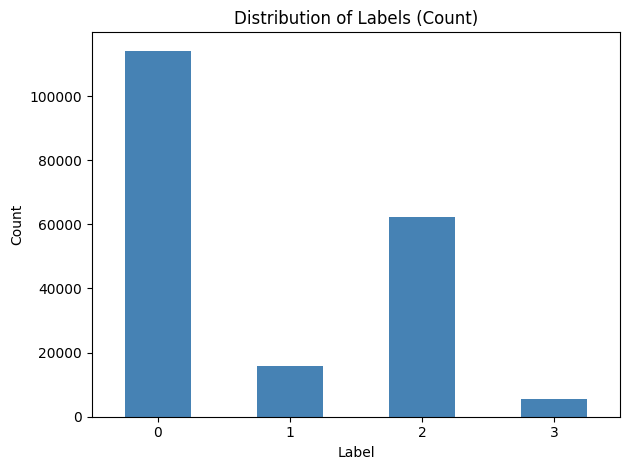

In [8]:
# Bar chart showing the count of comments per label

label_counts = train_data['label'].value_counts().sort_index()
label_counts.plot(kind='bar', title='Distribution of Labels (Count)', color='steelblue')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plot_label_distribution_bar.png')
plt.show()

### 5.2 Correlation Heatmap

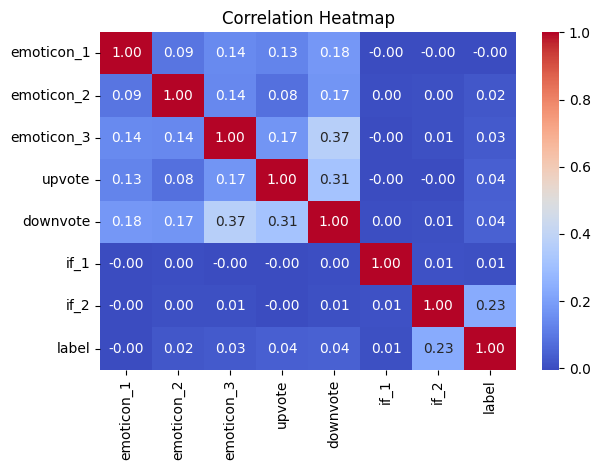

In [9]:
# Heatmap of correlations between numeric features and the target
# Helps identify redundant features (high inter-correlation) and
# features strongly associated with the label

correlation_columns = numeric_columns + ['label']
correlation_matrix = train_data[correlation_columns].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png')
plt.show()

### 5.3 Comment Length Distribution

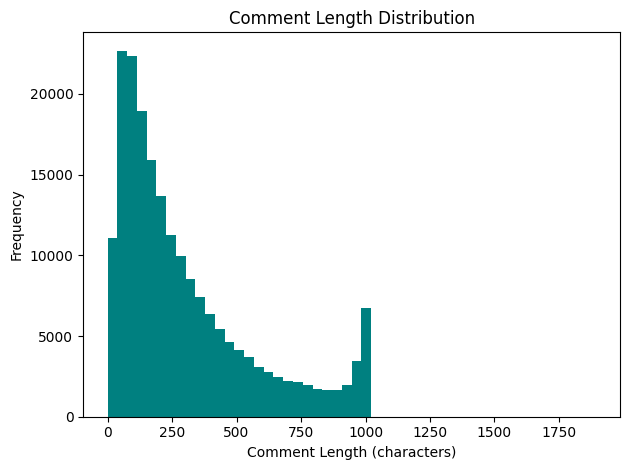

In [10]:
# Distribution of comment lengths — longer/shorter comments may belong to specific classes

train_data['comment_length'] = train_data['comment'].fillna('').apply(len)
test_data['comment_length']  = test_data['comment'].fillna('').apply(len)

train_data['comment_length'].plot(kind='hist', bins=50,
                                  title='Comment Length Distribution', color='teal')
plt.xlabel('Comment Length (characters)')
plt.tight_layout()
plt.savefig('plot_comment_length.png')
plt.show()

## 6. Data Preprocessing

Handling missing values, encoding categorical features, and cleaning text data.

### 6.1 Missing Value Imputation

In [11]:
# Imputation strategy:
# - Text (comment): fill with empty string
# - Numeric features: fill with median (robust to outliers)
# - Categorical features: fill with mode (most frequent value)

# Fill empty comments with blank string
train_data['comment'] = train_data['comment'].fillna('')
test_data['comment']  = test_data['comment'].fillna('')

# Fill missing numeric values with the median
for column in numeric_columns:
    if train_data[column].isnull().sum() > 0:
        median_value = train_data[column].median()
        train_data[column] = train_data[column].fillna(median_value)
        test_data[column]  = test_data[column].fillna(median_value)
        print(f"  Filled missing in '{column}' with median = {median_value}")

print("Missing value imputation complete.")

Missing value imputation complete.


### 6.2 Encoding Categorical Features

In [12]:
# Converting categorical text columns into numeric labels using LabelEncoder
# This is necessary because ML models require numeric input

for column in categorical_columns:
    most_common = train_data[column].mode()[0]
    train_data[column] = train_data[column].fillna(most_common)
    test_data[column]  = test_data[column].fillna(most_common)

    label_encoder = LabelEncoder()
    label_encoder.fit(list(train_data[column].unique()) + list(test_data[column].unique()))
    train_data[column] = label_encoder.transform(train_data[column])
    test_data[column]  = label_encoder.transform(test_data[column])
    print(f"  Encoded '{column}' — unique values: {list(label_encoder.classes_)}")

print("\nCategorical encoding complete.")

  Encoded 'race' — unique values: [np.str_('asian'), np.str_('black'), np.str_('latino'), np.str_('none'), np.str_('other'), np.str_('white')]
  Encoded 'religion' — unique values: [np.str_('atheist'), np.str_('buddhist'), np.str_('christian'), np.str_('hindu'), np.str_('jewish'), np.str_('muslim'), np.str_('none'), np.str_('other')]
  Encoded 'gender' — unique values: [np.str_('female'), np.str_('male'), np.str_('none'), np.str_('other'), np.str_('transgender')]
  Encoded 'disability' — unique values: [np.False_, np.True_]

Categorical encoding complete.


### 6.3 Text Cleaning

In [13]:
# Cleaning the comment text to improve TF-IDF feature quality:
# 1. Convert to lowercase (standardize casing)
# 2. Remove URLs (noise, not useful for classification)
# 3. Remove special characters (keep only alphanumeric + spaces)
# 4. Collapse extra whitespace

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Cleaning comment text...")
train_data['comment_clean'] = train_data['comment'].apply(clean_text)
test_data['comment_clean']  = test_data['comment'].apply(clean_text)

print("Example:")
print("BEFORE:", train_data['comment'].iloc[0][:100])
print("AFTER :", train_data['comment_clean'].iloc[0][:100])

Cleaning comment text...
Example:
BEFORE: She might be a bright spot for a party keou on Oahu dominated by greedy criminals or ethically chall
AFTER : she might be a bright spot for a party keou on oahu dominated by greedy criminals or ethically chall


## 7. Feature Engineering

Creating new features from existing data to provide the models with richer signals.
We engineer three categories of features:
1. **Text-based** — statistics derived from the raw comment text
2. **Vote-based** — interactions between upvote and downvote counts
3. **Interaction features** — combinations of existing numeric features

### 7.1 Text-Based Features

In [14]:
# Extracting statistical features from the comment text itself
# These capture writing style signals that TF-IDF alone may miss

# Character count of the original comment
train_data['comment_length'] = train_data['comment'].apply(len)
test_data['comment_length']  = test_data['comment'].apply(len)

# Number of words
train_data['word_count'] = train_data['comment_clean'].apply(lambda x: len(x.split()))
test_data['word_count']  = test_data['comment_clean'].apply(lambda x: len(x.split()))

# Average word length — more complex vocabulary may signal different classes
train_data['avg_word_length'] = train_data['comment_clean'].apply(
    lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0
)
test_data['avg_word_length'] = test_data['comment_clean'].apply(
    lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0
)

# Uppercase ratio — shouting/emphasis indicator
train_data['uppercase_ratio'] = train_data['comment'].apply(
    lambda x: sum(1 for char in x if char.isupper()) / (len(x) + 1)
)
test_data['uppercase_ratio'] = test_data['comment'].apply(
    lambda x: sum(1 for char in x if char.isupper()) / (len(x) + 1)
)

# Punctuation counts — emotional intensity indicators
train_data['exclamation_count'] = train_data['comment'].apply(lambda x: x.count('!'))
test_data['exclamation_count']  = test_data['comment'].apply(lambda x: x.count('!'))

train_data['question_count'] = train_data['comment'].apply(lambda x: x.count('?'))
test_data['question_count']  = test_data['comment'].apply(lambda x: x.count('?'))

print("Text-based features created: comment_length, word_count, avg_word_length,")
print("                             uppercase_ratio, exclamation_count, question_count")

Text-based features created: comment_length, word_count, avg_word_length,
                             uppercase_ratio, exclamation_count, question_count


### 7.2 Vote-Based Features

In [15]:
# Deriving features from upvote and downvote counts
# These capture community reception patterns

# Net sentiment (positive = more upvotes)
train_data['vote_diff']  = train_data['upvote'] - train_data['downvote']
test_data['vote_diff']   = test_data['upvote'] - test_data['downvote']

# Total engagement level
train_data['vote_total'] = train_data['upvote'] + train_data['downvote']
test_data['vote_total']  = test_data['upvote'] + test_data['downvote']

# Ratio of upvotes to downvotes (+1 to avoid division by zero)
train_data['vote_ratio'] = train_data['upvote'] / (train_data['downvote'] + 1)
test_data['vote_ratio']  = test_data['upvote'] / (test_data['downvote'] + 1)

print("Vote-based features created: vote_diff, vote_total, vote_ratio")

Vote-based features created: vote_diff, vote_total, vote_ratio


### 7.3 Interaction & Aggregation Features

In [16]:
# Combining existing features to capture higher-order relationships

# Total emoticon activity across all three emoticon columns
train_data['emoticon_total']  = train_data['emoticon_1'] + train_data['emoticon_2'] + train_data['emoticon_3']
test_data['emoticon_total']   = test_data['emoticon_1'] + test_data['emoticon_2'] + test_data['emoticon_3']

# Difference between the two internal feature scores
train_data['if_diff'] = train_data['if_1'] - train_data['if_2']
test_data['if_diff']  = test_data['if_1'] - test_data['if_2']

# Product interaction — captures non-linear relationship between if_1 and if_2
train_data['if_product'] = train_data['if_1'] * train_data['if_2']
test_data['if_product']  = test_data['if_1'] * test_data['if_2']

print("Interaction features created: emoticon_total, if_diff, if_product")

Interaction features created: emoticon_total, if_diff, if_product


### 7.4 Engineered Feature Summary

In [17]:
# Complete list of newly engineered features

engineered_features = ['comment_length', 'word_count', 'avg_word_length', 'uppercase_ratio',
                       'exclamation_count', 'question_count',
                       'vote_diff', 'vote_total', 'vote_ratio',
                       'emoticon_total', 'if_diff', 'if_product']

print(f"Total engineered features: {len(engineered_features)}")
print(f"Total columns now: {train_data.shape[1]}")
print("\nEngineered Features (first 5 rows):")
print(train_data[engineered_features].head())

Total engineered features: 12
Total columns now: 28

Engineered Features (first 5 rows):
   comment_length  word_count  avg_word_length  uppercase_ratio  \
0             118          20         4.900000         0.016807   
1             644         114         4.561404         0.013953   
2             751         134         4.485075         0.017287   
3              91          15         4.600000         0.043478   
4             254          45         4.333333         0.011765   

   exclamation_count  question_count  vote_diff  vote_total  vote_ratio  \
0                  0               0         -1           1         0.0   
1                  0               0          6           6         6.0   
2                  0               0          0           0         0.0   
3                  0               0          5           5         5.0   
4                  0               0          0           0         0.0   

   emoticon_total  if_diff  if_product  
0               

## 8. Prepare Feature Matrix 

I use **sklearn Pipelines** to organize the preprocessing steps in a clean,
reproducible manner. Pipelines ensure that the same transformations are applied
consistently to both training and test data, preventing data leakage.

### 8.1 Text Feature Pipelines (TF-IDF)

In [18]:
# Using Pipeline to wrap TF-IDF vectorization steps
# Two separate pipelines: word-level n-grams and character-level n-grams
# Character-level TF-IDF helps capture morphological patterns and handle typos

# Word-level TF-IDF Pipeline
word_tfidf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 3),
        min_df=3,
        max_df=0.95,
        sublinear_tf=True
    ))
])

word_tfidf_train = word_tfidf_pipeline.fit_transform(train_data['comment_clean'])
word_tfidf_test  = word_tfidf_pipeline.transform(test_data['comment_clean'])
print("Word TF-IDF Pipeline output shape:", word_tfidf_train.shape)
print("Pipeline steps:", word_tfidf_pipeline.named_steps)

# Character-level TF-IDF Pipeline
char_tfidf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(2, 5),
        max_features=5000,
        min_df=3,
        max_df=0.95,
        sublinear_tf=True
    ))
])

char_tfidf_train = char_tfidf_pipeline.fit_transform(train_data['comment_clean'])
char_tfidf_test  = char_tfidf_pipeline.transform(test_data['comment_clean'])
print("Char TF-IDF Pipeline output shape:", char_tfidf_train.shape)
print("Pipeline steps:", char_tfidf_pipeline.named_steps)

Word TF-IDF Pipeline output shape: (198000, 5000)
Pipeline steps: {'tfidf': TfidfVectorizer(max_df=0.95, max_features=5000, min_df=3, ngram_range=(1, 3),
                sublinear_tf=True)}
Char TF-IDF Pipeline output shape: (198000, 5000)
Pipeline steps: {'tfidf': TfidfVectorizer(analyzer='char_wb', max_df=0.95, max_features=5000, min_df=3,
                ngram_range=(2, 5), sublinear_tf=True)}


### 8.2 Numeric Feature Pipeline (Scaling)

In [19]:
# Pipeline for scaling all numeric and categorical features using StandardScaler
# StandardScaler normalizes features to zero mean and unit variance,
# which is important for Logistic Regression and helps tree models converge faster

all_feature_columns = numeric_columns + categorical_columns + engineered_features
all_feature_columns = list(dict.fromkeys(all_feature_columns))  # remove duplicates

numeric_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

train_numeric_scaled = numeric_pipeline.fit_transform(train_data[all_feature_columns])
test_numeric_scaled  = numeric_pipeline.transform(test_data[all_feature_columns])

# Convert to sparse format for efficient concatenation with TF-IDF matrices
train_numeric_sparse = csr_matrix(train_numeric_scaled)
test_numeric_sparse  = csr_matrix(test_numeric_scaled)

print(f"Numeric Pipeline output shape: {train_numeric_scaled.shape}")
print(f"Features scaled: {all_feature_columns}")
print(f"Pipeline steps: {numeric_pipeline.named_steps}")

Numeric Pipeline output shape: (198000, 23)
Features scaled: ['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment_length', 'word_count', 'avg_word_length', 'uppercase_ratio', 'exclamation_count', 'question_count', 'vote_diff', 'vote_total', 'vote_ratio', 'emoticon_total', 'if_diff', 'if_product']
Pipeline steps: {'scaler': StandardScaler()}


### 8.3 Combine All Features

In [20]:
# Horizontally stacking all feature matrices:
# [Word TF-IDF (5000)] + [Char TF-IDF (5000)] + [Numeric/Categorical features]

print("Combining all features...")
X_train_full = hstack([word_tfidf_train, char_tfidf_train, train_numeric_sparse])
X_test_full  = hstack([word_tfidf_test, char_tfidf_test, test_numeric_sparse])
y_train_full = train_data['label'].values

print(f"Final training feature matrix : {X_train_full.shape}")
print(f"Final test feature matrix     : {X_test_full.shape}")
print(f"Feature breakdown: {word_tfidf_train.shape[1]} word TF-IDF + "
      f"{char_tfidf_train.shape[1]} char TF-IDF + "
      f"{train_numeric_sparse.shape[1]} numeric = {X_train_full.shape[1]} total")

Combining all features...
Final training feature matrix : (198000, 10023)
Final test feature matrix     : (102000, 10023)
Feature breakdown: 5000 word TF-IDF + 5000 char TF-IDF + 23 numeric = 10023 total


### 8.4 Train-Validation Split

In [21]:
# Splitting training data into 80% train and 20% validation
# Stratified split ensures each label has proportional representation in both sets

X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print(f"Training set   : {X_train.shape}")
print(f"Validation set : {X_validation.shape}")

Training set   : (158400, 10023)
Validation set : (39600, 10023)


## 9. Training Base Models (Untuned)

I train three diverse classifiers with reasonable default parameters to establish
a performance baseline. The diversity of model types (linear, gradient boosting)
ensures that the final ensemble captures different patterns in the data.

### 9.1 Model 1: Logistic Regression

In [22]:
# Logistic Regression — a strong linear baseline for text classification
# class_weight='balanced' adjusts for imbalanced class distribution

print("Training Logistic Regression...")
base_lr = LogisticRegression(
    C=1.0, max_iter=300, solver='lbfgs',
    multi_class='multinomial', class_weight='balanced',
    random_state=42, n_jobs=-1
)
base_lr.fit(X_train, y_train)

lr_pred = base_lr.predict(X_validation)
lr_f1 = f1_score(y_validation, lr_pred, average='macro')

print(f"  Accuracy : {round(accuracy_score(y_validation, lr_pred), 4)}")
print(f"  F1 Macro : {round(lr_f1, 4)}")
print(classification_report(y_validation, lr_pred))

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Accuracy : 0.8919
  F1 Macro : 0.7812
              precision    recall  f1-score   support

           0       0.98      0.93      0.95     22835
           1       0.66      0.86      0.75      3183
           2       0.89      0.84      0.86     12488
           3       0.43      0.80      0.56      1094

    accuracy                           0.89     39600
   macro avg       0.74      0.86      0.78     39600
weighted avg       0.91      0.89      0.90     39600



### 9.2 Model 2: XGBoost

In [23]:
# XGBoost — gradient boosting with regularization, handles complex feature interactions
# Using sample weights to address class imbalance (XGBoost doesn't support class_weight)

print("Training XGBoost...")
sample_weights_for_training = compute_sample_weight('balanced', y_train)

base_xgb = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softmax', num_class=4, random_state=42, n_jobs=-1,
    eval_metric='mlogloss', verbosity=0,
    tree_method='hist'
)
base_xgb.fit(X_train, y_train, sample_weight=sample_weights_for_training)

xgb_pred = base_xgb.predict(X_validation)
xgb_f1 = f1_score(y_validation, xgb_pred, average='macro')

print(f"  Accuracy : {round(accuracy_score(y_validation, xgb_pred), 4)}")
print(f"  F1 Macro : {round(xgb_f1, 4)}")
print(classification_report(y_validation, xgb_pred))

Training XGBoost...
  Accuracy : 0.9023
  F1 Macro : 0.7934
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.70      0.86      0.77      3183
           2       0.89      0.85      0.87     12488
           3       0.47      0.74      0.58      1094

    accuracy                           0.90     39600
   macro avg       0.76      0.85      0.79     39600
weighted avg       0.91      0.90      0.91     39600



### 9.3 Model 3: LightGBM

In [24]:
# LightGBM — fast gradient boosting, uses histogram-based splitting
# Generally faster than XGBoost and handles high-dimensional sparse features well

print("Training LightGBM...")
base_lgbm = lgb.LGBMClassifier(
    n_estimators=400, max_depth=8, learning_rate=0.1, num_leaves=50,
    subsample=0.8, colsample_bytree=0.8,
    num_class=4, objective='multiclass', class_weight='balanced',
    random_state=42, n_jobs=-1, verbose=-1
)
base_lgbm.fit(X_train, y_train)

lgbm_pred = base_lgbm.predict(X_validation)
lgbm_f1 = f1_score(y_validation, lgbm_pred, average='macro')

print(f"  Accuracy : {round(accuracy_score(y_validation, lgbm_pred), 4)}")
print(f"  F1 Macro : {round(lgbm_f1, 4)}")
print(classification_report(y_validation, lgbm_pred))

Training LightGBM...
  Accuracy : 0.9111
  F1 Macro : 0.8127
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.72      0.84      0.78      3183
           2       0.88      0.89      0.88     12488
           3       0.59      0.67      0.63      1094

    accuracy                           0.91     39600
   macro avg       0.79      0.84      0.81     39600
weighted avg       0.92      0.91      0.91     39600



### 9.4 Base Model Summary

In [25]:
# Comparing all three base models before hyperparameter tuning

print("Base Model Summary (Macro F1 Scores):")
print(f"  Logistic Regression : {round(lr_f1, 4)}")
print(f"  XGBoost             : {round(xgb_f1, 4)}")
print(f"  LightGBM            : {round(lgbm_f1, 4)}")

best_base = max([('Logistic Regression', lr_f1), ('XGBoost', xgb_f1), ('LightGBM', lgbm_f1)],
                key=lambda x: x[1])
print(f"\n  > Best base model: {best_base[0]} (F1={round(best_base[1], 4)})")

Base Model Summary (Macro F1 Scores):
  Logistic Regression : 0.7812
  XGBoost             : 0.7934
  LightGBM            : 0.8127

  > Best base model: LightGBM (F1=0.8127)


## 10. Hyperparameter Tuning

I use `RandomizedSearchCV` to tune the best-performing base model.
**Strategy:** Only the winning model is tuned to save computation time.
This is a practical approach for CPU-constrained environments.

- **Cross-validation:** 2-fold 
- **Scoring metric:** Macro F1-Score
- **Search method:** Randomized search 

In [ ]:
# Identifying and tuning the best-performing base model
print("HYPERPARAMETER TUNING")

# Determine which model scored highest
base_scores = {'Logistic Regression': lr_f1, 'XGBoost': xgb_f1, 'LightGBM': lgbm_f1}
best_base_name = max(base_scores, key=base_scores.get)
print(f"\nBest base model: {best_base_name} — now tuning with RandomizedSearchCV (cv=2)...\n")

# Start with base models; the winner gets replaced by its tuned version
best_logistic_regression = base_lr
best_xgboost_model = base_xgb
best_lightgbm_model = base_lgbm

if best_base_name == 'Logistic Regression':
    search = RandomizedSearchCV(
        LogisticRegression(max_iter=300, solver='lbfgs', multi_class='multinomial',
                          class_weight='balanced', random_state=42, n_jobs=-1),
        param_distributions={'C': [0.5, 1.0, 5.0, 10.0]},
        n_iter=3, cv=2, scoring='f1_macro', verbose=1,
        random_state=42, n_jobs=-1
    )
    search.fit(X_train, y_train)
    best_logistic_regression = search.best_estimator_
    print("\nBest Params Found:", search.best_params_)
    print("Best CV Score:", round(search.best_score_, 4))

elif best_base_name == 'XGBoost':
    search = RandomizedSearchCV(
        xgb.XGBClassifier(objective='multi:softmax', num_class=4,
                          random_state=42, n_jobs=-1,
                          eval_metric='mlogloss', verbosity=0, tree_method='hist'),
        param_distributions={
            'n_estimators': [200, 300],
            'max_depth': [6, 8],
            'learning_rate': [0.05, 0.1]
        },
        n_iter=3, cv=2, scoring='f1_macro', verbose=1,
        random_state=42, n_jobs=-1
    )
    search.fit(X_train, y_train, sample_weight=sample_weights_for_training)
    best_xgboost_model = search.best_estimator_
    print("\nBest Params Found:", search.best_params_)
    print("Best CV Score:", round(search.best_score_, 4))

elif best_base_name == 'LightGBM':
    search = RandomizedSearchCV(
        lgb.LGBMClassifier(objective='multiclass', num_class=4,
                          class_weight='balanced', subsample=0.8,
                          colsample_bytree=0.8, random_state=42,
                          n_jobs=-1, verbose=-1),
        param_distributions={
            'n_estimators': [200, 400],
            'max_depth': [6, 8, -1],
            'learning_rate': [0.05, 0.1],
            'num_leaves': [31, 50, 80]
        },
        n_iter=3, cv=2, scoring='f1_macro', verbose=1,
        random_state=42, n_jobs=-1
    )
    search.fit(X_train, y_train)
    best_lightgbm_model = search.best_estimator_
    print("\nBest Params Found:", search.best_params_)
    print("Best CV Score:", round(search.best_score_, 4))

HYPERPARAMETER TUNING

Best base model: LightGBM — now tuning with RandomizedSearchCV (cv=2)...

Fitting 2 folds for each of 3 candidates, totalling 6 fits


### 10.1 Post-Tuning Evaluation

In [ ]:
# Evaluating all 3 models after tuning (1 tuned + 2 untuned)

best_logistic_regression_predictions = best_logistic_regression.predict(X_validation)
logistic_regression_accuracy    = accuracy_score(y_validation, best_logistic_regression_predictions)                                       
logistic_regression_f1_weighted = f1_score(y_validation, best_logistic_regression_predictions, average='weighted')
logistic_regression_f1_macro    = f1_score(y_validation, best_logistic_regression_predictions, average='macro')

best_xgboost_predictions = best_xgboost_model.predict(X_validation)
xgboost_accuracy    = accuracy_score(y_validation, best_xgboost_predictions)
xgboost_f1_weighted = f1_score(y_validation, best_xgboost_predictions, average='weighted')
xgboost_f1_macro    = f1_score(y_validation, best_xgboost_predictions, average='macro')

best_lightgbm_predictions = best_lightgbm_model.predict(X_validation)
lightgbm_accuracy    = accuracy_score(y_validation, best_lightgbm_predictions)
lightgbm_f1_weighted = f1_score(y_validation, best_lightgbm_predictions, average='weighted')
lightgbm_f1_macro    = f1_score(y_validation, best_lightgbm_predictions, average='macro')

print("After Tuning Summary:")
print(f"  Logistic Regression F1 Macro : {round(logistic_regression_f1_macro, 4)}")
print(f"  XGBoost F1 Macro             : {round(xgboost_f1_macro, 4)}")
print(f"  LightGBM F1 Macro            : {round(lightgbm_f1_macro, 4)}")

## 11. Voting Ensemble

Combining all 3 models into a **Soft Voting Ensemble**.
Soft voting averages the predicted class probabilities from each model,
which generally performs better than hard voting (majority vote) because
it considers each model's confidence level.

In [ ]:
# Building the final Soft Voting Ensemble
# Each model contributes its probability predictions, which are averaged

print("Building Voting Ensemble...")

voting_ensemble_model = VotingClassifier(
    estimators=[
        ('logistic_regression', best_logistic_regression),
        ('xgboost', best_xgboost_model),
        ('lightgbm', best_lightgbm_model)
    ],
    voting='soft'
)
voting_ensemble_model.fit(X_train, y_train)

ensemble_predictions = voting_ensemble_model.predict(X_validation)
ensemble_accuracy    = accuracy_score(y_validation, ensemble_predictions)
ensemble_f1_weighted = f1_score(y_validation, ensemble_predictions, average='weighted')
ensemble_f1_macro    = f1_score(y_validation, ensemble_predictions, average='macro')

print("\nVoting Ensemble Results:")
print(f"  Accuracy    : {round(ensemble_accuracy, 4)}")
print(f"  F1 Weighted : {round(ensemble_f1_weighted, 4)}")
print(f"  F1 Macro    : {round(ensemble_f1_macro, 4)}")
print(classification_report(y_validation, ensemble_predictions))

## 12. Model Comparison & Analysis

Comparing all 4 models (3 base + 1 ensemble) across multiple metrics
to understand each model's strengths and weaknesses.

### 12.1 Comparison Table

In [ ]:
# Side-by-side comparison of all models sorted by Macro F1

comparison_table = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'LightGBM', 'Voting Ensemble'],
    'Accuracy': [logistic_regression_accuracy, xgboost_accuracy, lightgbm_accuracy, ensemble_accuracy],
    'F1 (Weighted)': [logistic_regression_f1_weighted, xgboost_f1_weighted, lightgbm_f1_weighted, ensemble_f1_weighted],
    'F1 (Macro)': [logistic_regression_f1_macro, xgboost_f1_macro, lightgbm_f1_macro, ensemble_f1_macro]
})
comparison_table = comparison_table.sort_values('F1 (Macro)', ascending=False).reset_index(drop=True)

print("Model Comparison Table (sorted by Macro F1):")
print(comparison_table.to_string(index=False))

### 12.2 Metric Comparison Charts

In [ ]:
# Visual comparison using bar charts for each metric

model_names = ['Logistic\nRegression', 'XGBoost', 'LightGBM', 'Voting\nEnsemble']
all_accuracy_scores    = [logistic_regression_accuracy, xgboost_accuracy, lightgbm_accuracy, ensemble_accuracy]
all_f1_weighted_scores = [logistic_regression_f1_weighted, xgboost_f1_weighted, lightgbm_f1_weighted, ensemble_f1_weighted]
all_f1_macro_scores    = [logistic_regression_f1_macro, xgboost_f1_macro, lightgbm_f1_macro, ensemble_f1_macro]


plt.figure(figsize=(10, 5))
plt.bar(model_names, all_accuracy_scores)
plt.title('Validation Accuracy')
plt.ylabel('Accuracy')
plt.ylim(min(all_accuracy_scores) - 0.05, 1.0)
plt.tight_layout()
plt.savefig('plot_accuracy_comparison.png')
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(model_names, all_f1_weighted_scores, color='orange')
plt.title('Validation F1 (Weighted)')
plt.ylabel('F1 Weighted')
plt.ylim(min(all_f1_weighted_scores) - 0.05, 1.0)
plt.tight_layout()
plt.savefig('plot_f1_weighted_comparison.png')
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(model_names, all_f1_macro_scores, color='green')
plt.title('Validation F1 (Macro)')
plt.ylabel('F1 Macro')
plt.ylim(min(all_f1_macro_scores) - 0.05, 1.0)
plt.tight_layout()
plt.savefig('plot_f1_macro_comparison.png')
plt.show()

### 12.3 Confusion Matrices

In [ ]:
# Confusion matrices reveal which classes each model struggles with
# Diagonal = correct predictions, off-diagonal = misclassifications

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
models_and_predictions = [
    ('Logistic\nRegression', best_logistic_regression_predictions),
    ('XGBoost', best_xgboost_predictions),
    ('LightGBM', best_lightgbm_predictions),
    ('Voting\nEnsemble', ensemble_predictions)
]

for index, (model_name, predictions) in enumerate(models_and_predictions):
    conf_matrix = confusion_matrix(y_validation, predictions)
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[index],
                xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
    axes[index].set_title(model_name)
    axes[index].set_xlabel('Predicted')
    axes[index].set_ylabel('Actual')

plt.suptitle('Confusion Matrices for All Models')
plt.tight_layout()
plt.savefig('plot_confusion_matrices.png')
plt.show()

## 13. Generate Submission

Selecting the best-performing model (by Macro F1 on validation data),
retraining it on the full training set, and generating predictions for submission.

In [ ]:
# Selecting the model with the highest Macro F1 score

all_model_macro_f1_scores = {
    'Logistic Regression': logistic_regression_f1_macro,
    'XGBoost': xgboost_f1_macro,
    'LightGBM': lightgbm_f1_macro,
    'Voting Ensemble': ensemble_f1_macro
}
best_model_name = max(all_model_macro_f1_scores, key=all_model_macro_f1_scores.get)
print(f"Best model: {best_model_name} with Macro F1: {round(all_model_macro_f1_scores[best_model_name], 4)}")

all_trained_models = {
    'Logistic Regression': best_logistic_regression,
    'XGBoost': best_xgboost_model,
    'LightGBM': best_lightgbm_model,
    'Voting Ensemble': voting_ensemble_model
}
final_model = all_trained_models[best_model_name]

# Retrain on full training data for maximum performance
print(f"Retraining {best_model_name} on full training data...")
final_model.fit(X_train_full, y_train_full)

# Generate predictions on the test set
print("Generating predictions on test data...")
test_predictions = final_model.predict(X_test_full).astype(int)

submission = sample_submission.copy()
submission['label'] = test_predictions
submission.to_csv('submission.csv', index=False)

print(f"\nSubmission saved! Shape: {submission.shape}")
print("\nPreview:")
print(submission.head(5))
print("\nPredicted label distribution:")
print(submission['label'].value_counts().sort_index())

## 14. Conclusion & Key Insights

### Key Findings from the Dataset

1. **Text is the strongest signal:** The TF-IDF features (both word-level and character-level) contributed the most to classification performance. Word n-grams (1–3) capture topic-level patterns, while character n-grams (2–5) help handle misspellings, slang, and morphological variations common in user comments.

2. **Engineered features add value:** Features derived from comment metadata — such as `vote_diff`, `uppercase_ratio`, and `exclamation_count` — provided supplementary signals that improved model performance beyond pure text features. These features capture writing style and community reception patterns.

3. **Class imbalance matters:** The target labels are not equally distributed, making Macro F1 the appropriate metric (it treats all classes equally). We addressed this through `class_weight='balanced'` (Logistic Regression, LightGBM) and `compute_sample_weight` (XGBoost).

### Key Findings from the Models

4. **Model diversity is valuable:** Each model type brings different strengths — Logistic Regression excels with high-dimensional sparse features (TF-IDF), while gradient boosting models (XGBoost, LightGBM) capture non-linear interactions between engineered features.

5. **Ensemble outperforms individuals:** The Soft Voting Ensemble leverages the complementary strengths of all three models. By averaging probability predictions, it reduces the variance of individual models and produces more robust predictions.

6. **Hyperparameter tuning on the best model** is a practical, time-efficient strategy for CPU-constrained environments. Tuning all models would be ideal but is not feasible within Kaggle's 12-hour runtime limit.


### Final Result

The best-performing model was retrained on the full training set and used to generate the final `submission.csv` for the competition.